# Mastercard stock price prediction

We will build several models that try to predict the Mastercard stock price.

# Data

- Date - date
- Open - opening price
- High - highest price
- Low - lowest price
- Close - closing price
- Volume - number of shares traded
- Dividends - dividends paid out
- Stock Splits - a stock split is a situation when a company increases the number of its outstanding shares to increase their liquidity.


For prediction we will use the High column.

# Loading data and data analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

We load the data and immediately drop the unneeded columns.

In [ ]:
dataset = pd.read_csv("..\\dataset\\Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"]).drop(["Dividends", "Stock Splits"], axis=1)

In [ ]:
dataset.head()

In [ ]:
dataset.describe()

In [ ]:
dataset.isna().sum()

Plotting the stock price development
* We will use data from 2016 to 2021 for training
* We will use data from 2022 for model validation

In [ ]:
trainig_start = 2016
training_end = 2020

def train_test_plot(dataset, trainig_start, training_end):
    dataset.loc[f"{trainig_start}":f"{training_end}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{training_end + 1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (2016 - 2020)", "Test (2021)"])
    plt.title("MasterCard Stock Price")
    plt.show()

train_test_plot(dataset,trainig_start, training_end)

# Data preparation

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

Splitting the data into training and testing sets.

- Training data is from 2016 to 2020.
- Testing data is for the year 2021.

In [ ]:
trainig_start = 2016
training_end = 2020

def train_test_split(dataset, trainig_start, training_end):
    train = dataset.loc[f"{trainig_start}":f"{training_end}", "High"].values
    test = dataset.loc[f"{training_end+1}":, "High"].values
    return train, test

training_data, testing_data = train_test_split(dataset, trainig_start, training_end)

In [ ]:
print (f"Training data shape {training_data.shape}")
print (f"Testing data shape {testing_data.shape}")

Checking the first stock price

In [ ]:
training_data[0]

To standardize the training set we use the MinMaxScaler function, which helps us avoid outlier values or anomalies.

You can also try using the StandardScaler function or any other scaling function to normalize the data and improve model performance.

In [ ]:
sc = MinMaxScaler(feature_range=(0, 1))
training_data = training_data.reshape(-1, 1)
training_data_scaled = sc.fit_transform(training_data)

Checking the first standardized stock price

In [ ]:
training_data_scaled[0]

The split_sequence function takes the training dataset and converts it into inputs (X_train) and outputs (y_train).

For example, if the sequence is [1,2,3,4,5,6,7,8,9,10,11,12] and n_steps is three, it converts the sequence into three input timestamps and one output.



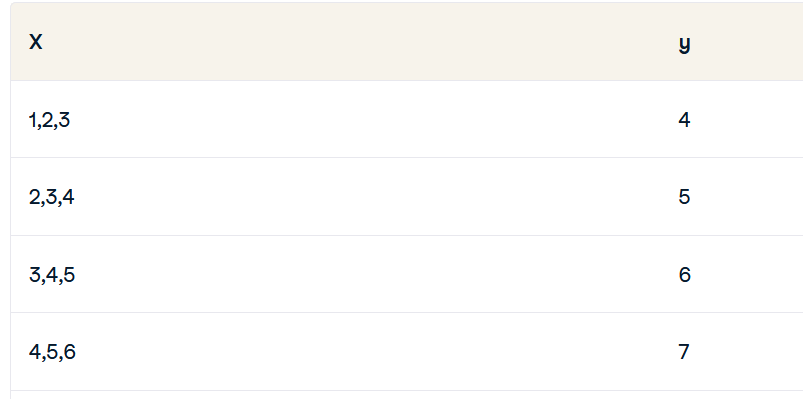

In [ ]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


n_steps = 80
features = 1

X_train, y_train = split_sequence(training_data_scaled, n_steps)

Checking the shape of the arrays

In [ ]:
print (X_train.shape)
print (y_train.shape)

Checking the training data

In [ ]:
X_train[0]

Checking the output data

In [ ]:
y_train[0]

We are working with one-dimensional series, so the number of features is one, and we need to reshape X_train to match the LSTM model.

X_train has [samples, timesteps] and we reshape it to [samples, timesteps, features].

In our case features = 1

In [ ]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],features)

Adjusting the training data

In [ ]:
inputs = testing_data
inputs = inputs.reshape(-1, 1)

# standardization
inputs = sc.transform(inputs)

# Splitting the data
X_test, y_test = split_sequence(inputs, n_steps)

# Reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)

# Simple RNN
The first model will be a simple recurrent neural network.

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Input

Again, it will be a sequential network.

In [ ]:
model_simple = Sequential()

The input data has the following dimensions:
* features = 1, one variable
* n_steps = 80, a series of 80 input values

In [ ]:
model_simple.add(Input(shape=(n_steps, features))) 

You can experiment with the number of units, as more units will give you better results.

* units
* activation - the activation function

In [ ]:
model_simple.add(SimpleRNN(units=125,                          
                           activation="tanh",                 
                           ))  

Then we add the output layer, which returns a single value.

In [ ]:
model_simple.add(Dense(units=1))

Displaying the network structure.

In [ ]:
model_simple.summary()

In [ ]:
from keras_visualizer import visualizer 
visualizer(model_simple, file_format='png', view=True)

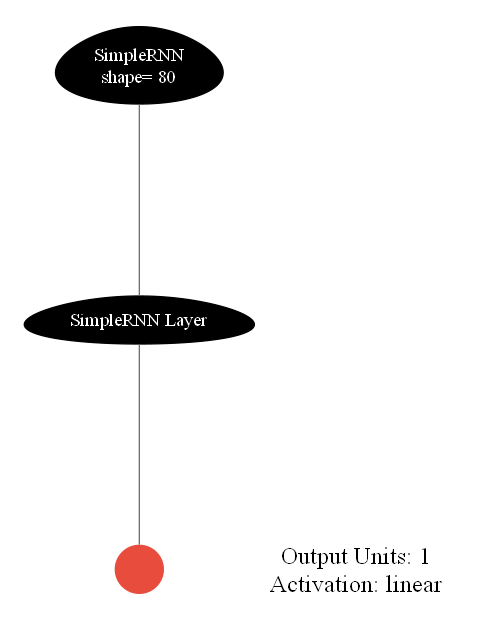

Setting the training parameters

In [ ]:
model_simple.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])

Creating the early stop

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30)

Training the neural network

In [ ]:
history_simple = model_simple.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

### Displaying the training history

In [ ]:
plt.plot(history_simple.history['loss'], label='Train Loss')
plt.plot(history_simple.history['val_loss'], label='Val Loss')
plt.plot(history_simple.history['mae'], label='Train MAE')
plt.plot(history_simple.history['val_mae'], label='Val MAE')
plt.legend(loc="right")
plt.title('Loss and MAE')
plt.ylabel('Loss and MAE')
plt.xlabel('Number of epochs')
plt.show()

### Model verification

Predicting future stock values

In [ ]:
predicted_stock_price = model_simple.predict(X_test)

Inverting the result from standardized values to actual values

In [ ]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

#### Displaying the chart

In [ ]:
def plot_predictions(test, predicted):
    """Plot predicted vs. real stock price values."""
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard Stock Price")
    plt.legend()
    plt.show()

In [ ]:
plot_predictions(testing_data[n_steps:], predicted_stock_price)

#### RMSE
The deviations of the real and predicted values.

Note that this is an absolute number.

In [ ]:
def rmse(test, predicted):    
    return np.sqrt(mean_squared_error(test, predicted))

In [ ]:
print("RMSE {:.2f}.".format(rmse(testing_data[n_steps:], predicted_stock_price)))

#### sMAPE

sMAPE is a better metric for evaluating time series. It is often expressed as a percentage.

sMAPE = mean( |y − ŷ| / (|y| + |ŷ|) )

In [ ]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(numerator / (denominator + eps)) * 100

The prediction often missed the mark.

In [ ]:
print(f"sMAPE: {smape(testing_data[n_steps:], predicted_stock_price):.2f} %")

#### Directional Accuracy (DA)
Sometimes only the direction matters, not the magnitude.

For instance, in finance this can indicate whether to buy or sell.

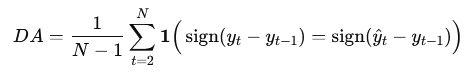

In [ ]:
def directional_accuracy(y_true, y_pred):
    true_diff = y_true[1:] - y_true[:-1]
    pred_diff = y_pred[1:] - y_pred[:-1]
    correct_direction = np.sign(true_diff) == np.sign(pred_diff)
    return np.mean(correct_direction)

In [ ]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[n_steps:], predicted_stock_price) * 100:.3f} %")

# LSTM neural network

In [ ]:
from keras.layers import Dense, LSTM, GRU, Dropout
from keras.optimizers import SGD

The model consists of one hidden LSTM layer and an output layer.

You can experiment with the number of units, as more units will give you better results.

For this experiment we set the number of LSTM units to 125, tanh as the activation, and set the input size.

Finally, we compile the model using the RMSprop optimizer and mean squared error as the loss function.

In [ ]:
model_lstm = Sequential()
model_lstm.add(Input(shape=(n_steps, features))) 
model_lstm.add(LSTM(units=125, activation="tanh"))
model_lstm.add(Dense(units=1))

Displaying the network structure.

In [ ]:
model_lstm.summary()

In [ ]:
from keras_visualizer import visualizer 
visualizer(model_lstm, file_format='png', view=True)

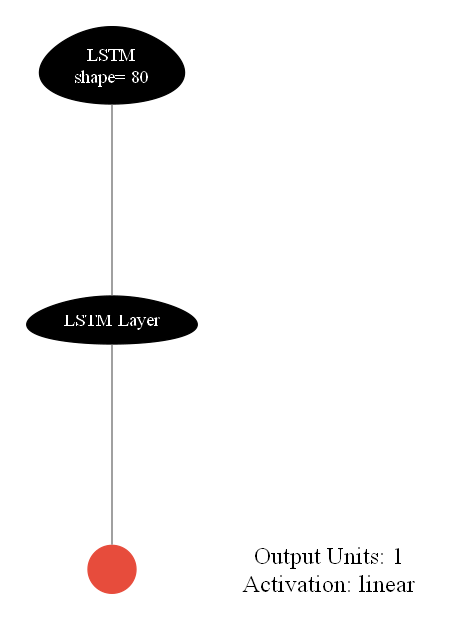

Compiling and training the network

In [ ]:
model_lstm.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30)

In [ ]:
history_lstm = model_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

### Displaying the training history

In [ ]:
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.plot(history_lstm.history['mae'], label='Train MAE')
plt.plot(history_lstm.history['val_mae'], label='Val MAE')
plt.legend(loc="right")
plt.title('Loss, MAE')
plt.ylabel('Loss, MAE')
plt.xlabel('Number of epochs')
plt.show()

### LSTM model verification

In [ ]:
predicted_stock_price = model_lstm.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

#### Chart

In [ ]:
plot_predictions(testing_data[n_steps:], predicted_stock_price)

#### RMSE

In [ ]:
print("RMSE {:.2f}.".format(rmse(testing_data[n_steps:], predicted_stock_price)))

#### sMAPE

In [ ]:
print(f"sMAPE: {smape(testing_data[n_steps:], predicted_stock_price):.2f} %")

#### Directional Accuracy (DA)

In [ ]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[n_steps:], predicted_stock_price) * 100:.3f} %")

# GRU model
A model based on the Gated Recurrent Unit.

In [ ]:
model_gru = Sequential()
model_gru.add(Input(shape=(n_steps, features))) 
model_gru.add(GRU(units=125, activation="tanh"))
model_gru.add(Dense(units=1))

Displaying the network structure

In [ ]:
model_gru.summary()

In [ ]:
from keras_visualizer import visualizer 
visualizer(model_gru, file_format='png', view=True)

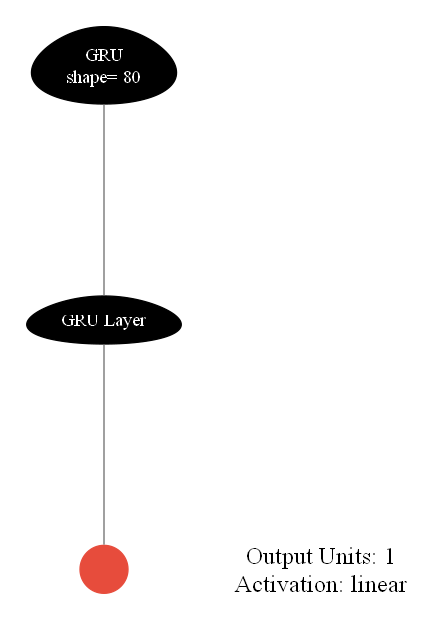

Training the neural network

In [ ]:
model_gru.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30)

In [ ]:
history_gru = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

### Displaying the training history

In [ ]:
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.plot(history_gru.history['mae'], label='Train MAE')
plt.plot(history_gru.history['val_mae'], label='Val MAE')
plt.legend(loc="right")
plt.title('Loss, MAE')
plt.ylabel('Loss, MAE')
plt.xlabel('Number of epochs')
plt.show()

### GRU model verification

In [ ]:
predicted_stock_price = model_gru.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

#### Chart

In [ ]:
plot_predictions(testing_data[n_steps:], predicted_stock_price)

#### RMSE

In [ ]:
print("RMSE {:.2f}.".format(rmse(testing_data[n_steps:], predicted_stock_price)))

#### sMAPE

In [ ]:
print(f"sMAPE: {smape(testing_data[n_steps:], predicted_stock_price):.2f} %")

#### Directional Accuracy (DA)

In [ ]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[n_steps:], predicted_stock_price) * 100:.3f} %")

# Results
Stock prices behave very randomly — their movement is largely unpredictable, and the best estimate of tomorrow's price is today's price. Prices are also influenced by irrational trader behavior, where traders project their feelings, overreactions to unexpected situations, etc., into their trades.

## Implications for our models:

- The networks mainly learn to predict tomorrow's price based on today's price. This is the mathematically optimal strategy for minimizing MSE on a random walk.
- A Directional Accuracy of ~49% corresponds to a random coin flip — the model does not predict the direction of movement better than chance.
- The differences between SimpleRNN, LSTM, and GRU are minimal, because none of them can extract patterns that simply aren't present in the data.
- Recurrent networks work well where the data actually has a temporal structure — for example seasonality (temperatures, electricity consumption, passenger counts) or periodic cycles. This condition is not met in the stock market, which is why the best available models achieve results comparable to the trivial baseline "tomorrow will be the same as today".